In [ ]:
#Assignment No 04


In [ ]:
#import required libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

In [6]:
titanic = pd.read_csv("Titanic-Dataset.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
titanic.drop(columns=["PassengerId","Name","Ticket","Cabin"], inplace=True)

titanic["Age"].fillna(titanic["Age"].median(), inplace=True)
titanic["Embarked"].fillna(titanic["Embarked"].mode()[0], inplace=True)

le = LabelEncoder()
titanic["Sex"] = le.fit_transform(titanic["Sex"])
titanic["Embarked"] = le.fit_transform(titanic["Embarked"])

X = titanic.drop("Survived", axis=1)
y = titanic["Survived"]

C:\Users\HP\AppData\Local\Temp\ipykernel_10384\1659986038.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["Age"].fillna(titanic["Age"].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_10384\1659986038.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [10]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# Baseline XGBoost Model (Before Tuning)
xgb = XGBClassifier(
    objective="binary:logistic",
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.8100558659217877


In [12]:
# Hyperparameter Tuning using GridSearchCV
param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[3,4,5,6],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.7,0.8,1],
    'colsample_bytree':[0.7,0.8,1]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(objective="binary:logistic",eval_metric="logloss"),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train,y_train)

print("Best Parameters:",grid_search.best_params_)
print("Best Score:",grid_search.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1}
Best Score: 0.8301881217374175


In [13]:
# Model After GridSearch Tuning
best_grid_model = grid_search.best_estimator_

y_pred_grid = best_grid_model.predict(X_test)

grid_accuracy = accuracy_score(y_test,y_pred_grid)

print("Accuracy after GridSearch:",grid_accuracy)

Accuracy after GridSearch: 0.7877094972067039


In [14]:
# Hyperparameter Tuning using RandomizedSearchCV
param_dist = {
    'n_estimators':[100,200,300,400],
    'max_depth':[3,4,5,6,7],
    'learning_rate':[0.01,0.05,0.1,0.2],
    'subsample':[0.6,0.7,0.8,1],
    'colsample_bytree':[0.6,0.7,0.8,1],
    'gamma':[0,0.1,0.2,0.3]
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(objective="binary:logistic",eval_metric="logloss"),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train,y_train)

print("Best Parameters:",random_search.best_params_)

Best Parameters: {'subsample': 1, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 1}


In [15]:
# Model After Random Search
best_random_model = random_search.best_estimator_

y_pred_random = best_random_model.predict(X_test)

random_accuracy = accuracy_score(y_test,y_pred_random)

print("Accuracy after RandomSearch:",random_accuracy)

Accuracy after RandomSearch: 0.7821229050279329


In [16]:
#Classification Report
print("Classification Report:\n")
print(classification_report(y_test,y_pred_random))

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.87      0.83       110
           1       0.76      0.64      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



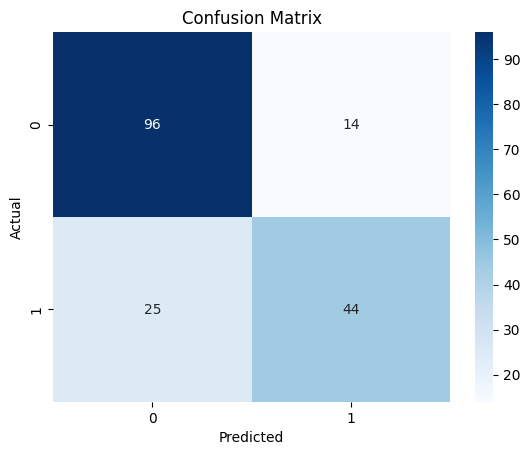

In [ ]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test,y_pred_random)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#Accuarcy
print("Baseline XGBoost Accuracy:", baseline_accuracy)
print("GridSearch Tuned Accuracy:", grid_accuracy)
print("RandomSearch Tuned Accuracy:", random_accuracy)

Baseline XGBoost Accuracy: 0.8100558659217877
GridSearch Tuned Accuracy: 0.7877094972067039
RandomSearch Tuned Accuracy: 0.7821229050279329


In [23]:
accuracies = {
    "Baseline XGBoost": baseline_accuracy,
    "GridSearch XGBoost": grid_accuracy,
    "RandomSearch XGBoost": random_accuracy
}

best_model = max(accuracies, key=accuracies.get)

print("Best Performing Model:", best_model)
print("Best Accuracy:", accuracies[best_model])

Best Performing Model: Baseline XGBoost
Best Accuracy: 0.8100558659217877


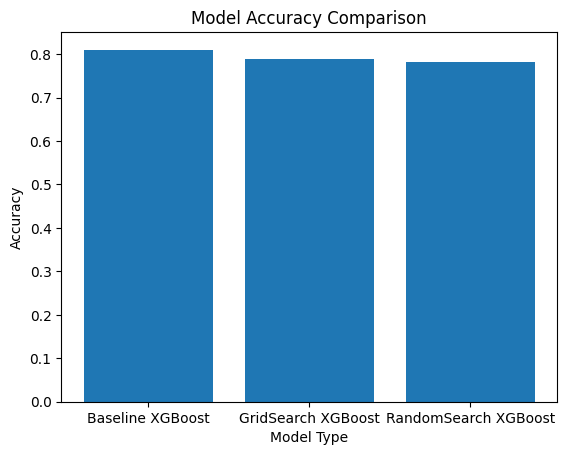

In [18]:
# Accuracy Comparison Visualization
models = ["Baseline XGBoost","GridSearch XGBoost","RandomSearch XGBoost"]
accuracies = [baseline_accuracy,grid_accuracy,random_accuracy]

plt.bar(models,accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model Type")
plt.show()

<Figure size 800x600 with 0 Axes>

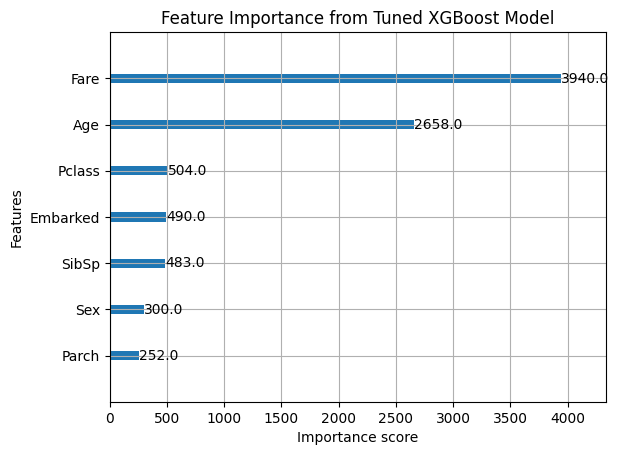

In [ ]:
# Feature Importance Visualization
import xgboost as xgb

plt.figure(figsize=(8,6))

xgb.plot_importance(best_random_model)

plt.title("Feature Importance from Tuned XGBoost Model")

plt.show()